In [52]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST

In [53]:
at = np.arange(30,80,10)
print(at)

file_indices = [1,2,3,4,5]
print(file_indices)

[30 40 50 60 70]
[1, 2, 3, 4, 5]


In [54]:
file_template = "../axial_tilt/output{}.nc"
results = []

In [55]:
for idx in file_indices:
    fname = file_template.format(idx)

    # Ensure file exists
    if not Path(fname).exists():
        print(f"Warning: {fname} not found, skipping.")
        continue

    # Prepare containers for this file/run
    run = {
        "month": [],
        "ice_tot": [], "ice_nhem": [], "ice_shem": [],
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
        "sst_tot": [], "sst_nhem": [], "sst_shem": []
    }
    
    # Open dataset and process
    with xr.open_dataset(fname) as ds:
        ds_crop = ds.sel(time=slice("2001-01-01", "2002-01-01"))
        monthly_data = ds_crop.groupby("time.month")
        months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
        run["month"].append(months)

        for month, data in monthly_data:

            # Whole globe
            ice_frac = SeaIceCalc.ice_frac(data)[0]
            fraction_sm = Habitability.fraction(data, "sm")[0]
            fraction_st = Habitability.fraction(data, "st")[0]
            fraction_tsurf = Habitability.fraction(data, "tsurf")[0]
            sst_tot = SST.temp(data)

            run["ice_tot"].append(ice_frac)
            run["sm_tot"].append(fraction_sm)
            run["st_tot"].append(fraction_st)
            run["tsurf_tot"].append(fraction_tsurf)
            run["sst_tot"].append(sst_tot)

            # Northern hemisphere
            ice_n = SeaIceCalc.ice_frac(data, lat=slice(0,24))[0]
            sm_n = Habitability.fraction(data, "sm", lat=slice(0,24))[0]
            st_n = Habitability.fraction(data, "st", lat=slice(0,24))[0]
            tsurf_n = Habitability.fraction(data, "tsurf", lat=slice(0,24))[0]
            sst_n = SST.temp(data, lat=slice(0,24))

            run["ice_nhem"].append(ice_n)
            run["sm_nhem"].append(sm_n)
            run["st_nhem"].append(st_n)
            run["tsurf_nhem"].append(tsurf_n)
            run["sst_nhem"].append(sst_n)

            # Southern hemisphere
            ice_s = SeaIceCalc.ice_frac(data, lat=slice(24,48))[0]
            sm_s = Habitability.fraction(data, "sm", lat=slice(24,48))[0]
            st_s = Habitability.fraction(data, "st", lat=slice(24,48))[0]
            tsurf_s = Habitability.fraction(data, "tsurf", lat=slice(24,48))[0]
            sst_s = SST.temp(data, lat=slice(24,48))

            run["ice_shem"].append(ice_s)
            run["sm_shem"].append(sm_s)
            run["st_shem"].append(st_s)
            run["tsurf_shem"].append(tsurf_s)
            run["sst_shem"].append(sst_s)

    # convert lists to numpy arrays (for math/plotting later)
    for k in run:
        if run[k] is None:
            continue
        if isinstance(run[k], list):
            run[k] = np.array(run[k]) 

    # Store results
    results.append({"file": fname, "data": run})


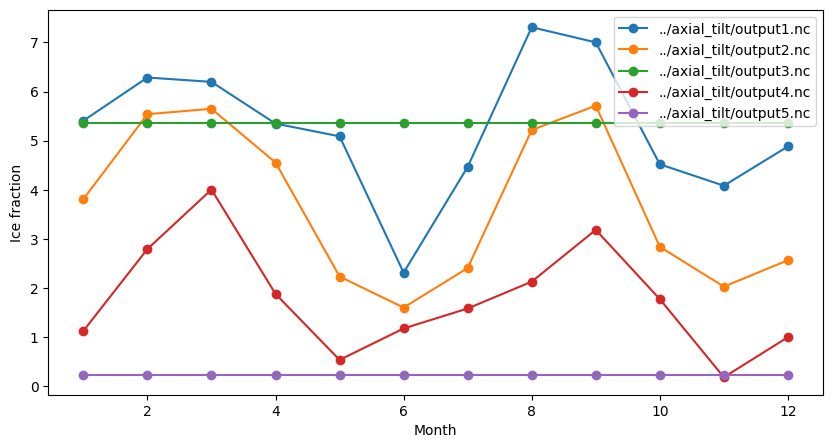

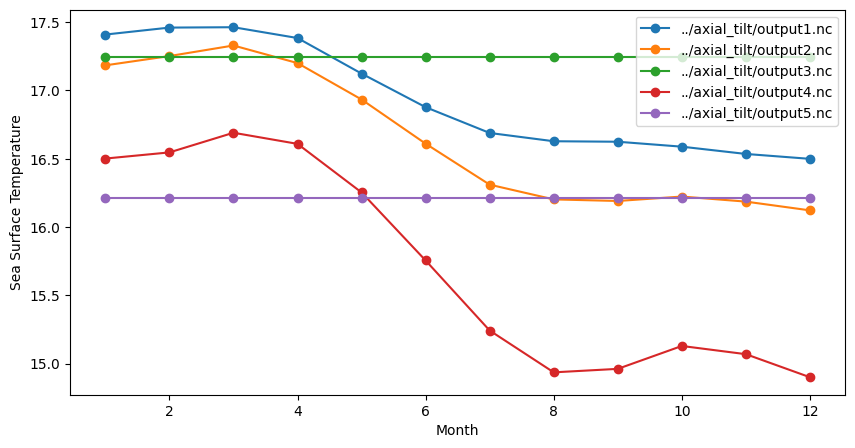

In [57]:
fig = plt.figure(figsize=(10, 5))
for r in results[0:5]:
    ice = r["data"]["ice_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, ice, marker='o', label=r["file"])
plt.xlabel("Month")
plt.ylabel("Ice fraction")
plt.legend(loc="upper right")
plt.show()

fig = plt.figure(figsize=(10, 5))
for r in results[0:5]:
    sst = r["data"]["sst_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sst, marker='o', label=r["file"])
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature")
plt.legend(loc="upper right")
plt.show()

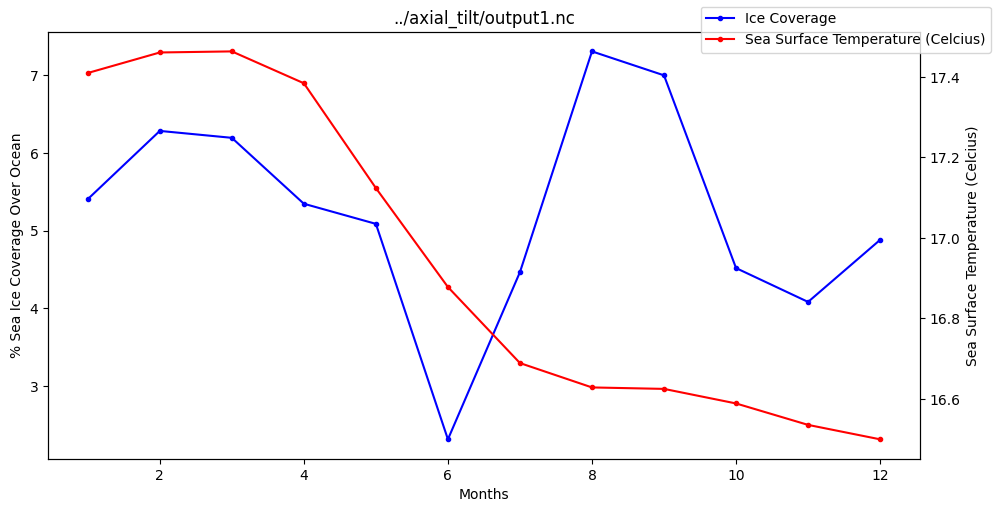

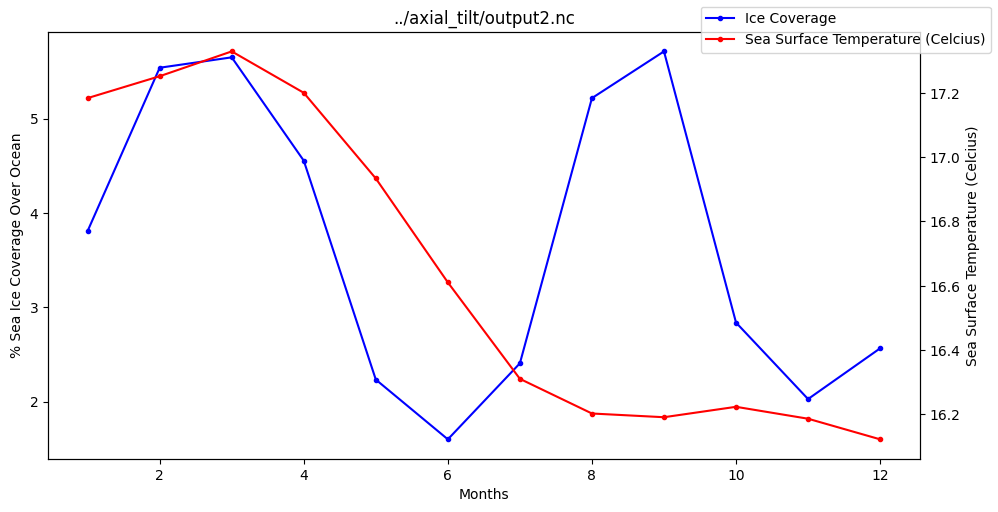

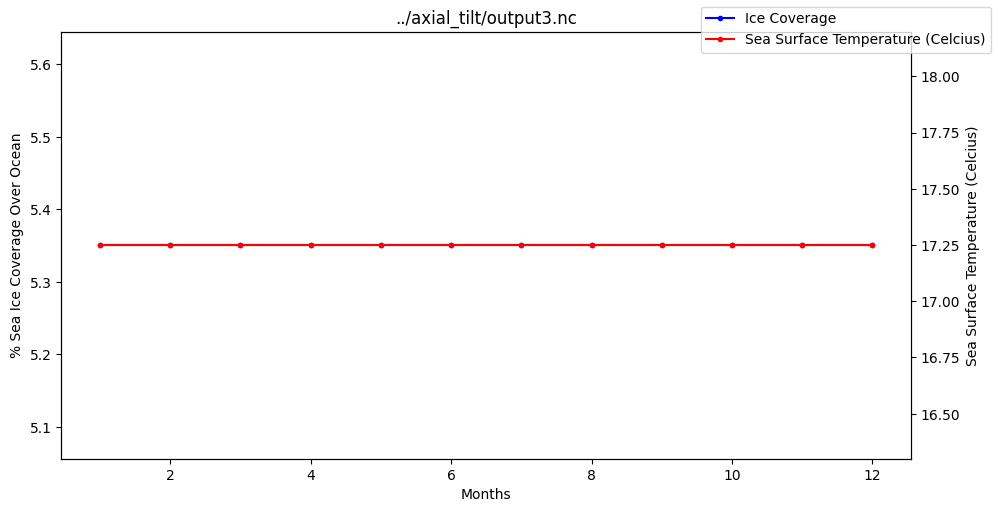

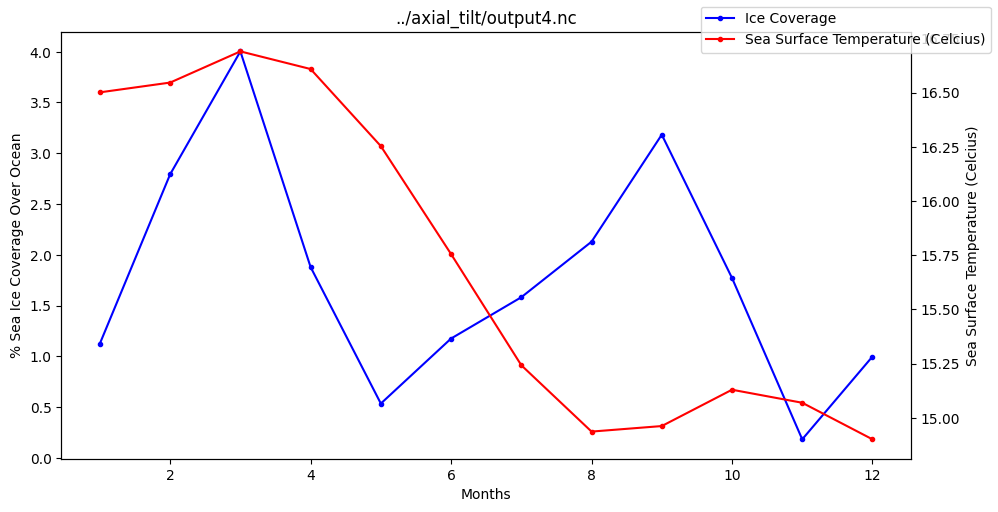

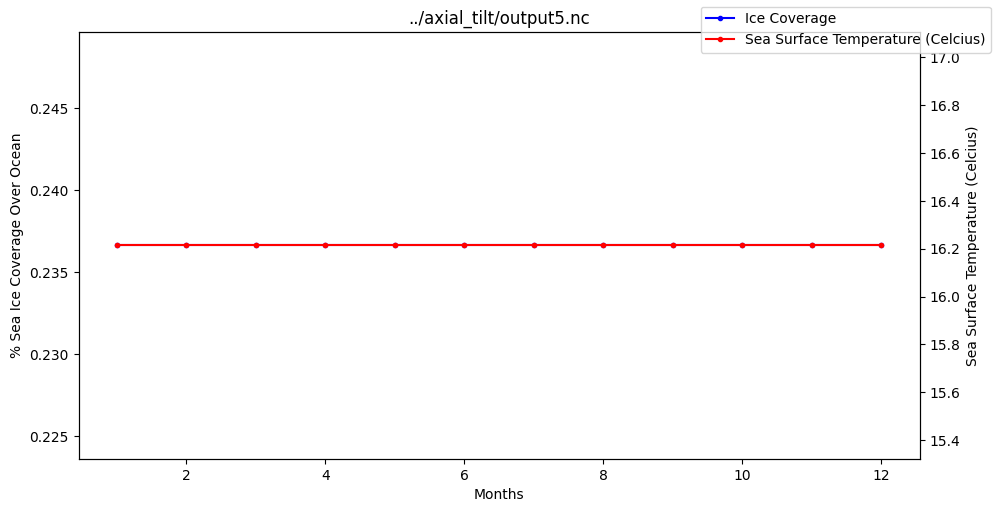

In [59]:
for r in results[0:5]:
    sst = r["data"]["sst_tot"]
    sic = r["data"]["ice_tot"]
    month = r["data"]["month"][0]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # First y-axis
    ax1.plot(month, sic, marker='.', color='blue', label="Ice Coverage")
    ax1.set_xlabel("Months")
    ax1.set_ylabel("% Sea Ice Coverage Over Ocean")

    # Second y-axis (shares the same x-axis)
    ax2 = ax1.twinx()
    ax2.plot(month, sst, marker='.', color='red', label="Sea Surface Temperature (Celcius)")
    ax2.set_ylabel("Sea Surface Temperature (Celcius)")

    fig.legend(loc="upper right")
    plt.tight_layout()
    plt.title(r["file"])
    plt.show()